## Import

In [ ]:
#드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None) # 전체 행 보여 주기

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import re

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_auc_score

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

import lightgbm as lgb


## Data Load & Check Data

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/open/train.csv')
test = pd.read_csv('/content/drive/MyDrive/open/test.csv')

## Pre-Processing

In [ ]:
#의미 없는 값 삭제
train = train.drop(columns=['class2','class3','class4','completed_semester','ID', 'generation','contest_award','nationality','idea_contest','contest_participation'], errors='ignore')
test = test.drop(columns=['class2','class3','class4','completed_semester','ID', 'generation','contest_award','nationality','idea_contest','contest_participation'], errors='ignore')

In [ ]:
train['school1'] = train['school1'].astype('category')
test['school1'] = test['school1'].astype('category')

In [ ]:

def preprocess_majors(df):

    # 2. 전공 통합 로직
    # major1_2(제2전공)가 결측치가 아니면 'Double_Major', 아니면 'Single_Major'로 1차 분류
    # 여기에 major1_1(제1전공)의 텍스트 정보를 결합할 수 있습니다.

    def get_major_status(row):
        m1 = str(row['major1_1']).strip()
        # 제2전공이 존재하는지 확인 (null이거나 'nan' 문자열인 경우 제외)
        has_double = pd.notnull(row['major1_2']) and str(row['major1_2']).lower() != 'nan'

        if has_double:
            return f"Double_{m1}" # 예: Double_경영학
        else:
            return f"Single_{m1}" # 예: Single_컴퓨터공학

    df['major_combined'] = df.apply(get_major_status, axis=1)

    # 사용한 원본 전공 컬럼들 제거
    df = df.drop(columns=['major type', 'major1_1', 'major1_2'], errors='ignore')

    return df

def regroup_inflow(route):
    # 1. 인적 네트워크 그룹 (유대감 기반)
    if route in ['기존 학회원 또는 운영진', '지인 추천']:
        return 'Network'

    # 2. 공개 채널 그룹 (광고/검색 기반)
    if route in ['에브리타임', '인스타그램', '대외활동 사이트(링커리어, 캠퍼스픽, 캠퍼즈, 위비티 등)', '인터넷 검색']:
        return 'Open'

def transform_gain_goal(text):
    text = str(text).strip()

    # 1. 표준 선택지 4가지 매핑
    if text == '데이터 분석 역량':
        return 1
    elif text == '프로젝트 경험':
        return 2
    elif text == '공모전 경험':
        return 3
    elif text == '인적 네트워크':
        return 4
    else:
        return 5 # 'Special / Extra Goal' 그룹

def clean_previous_classes(df):
    prev_cols = [f'previous_class_{i}' for i in range(3, 9)]

    # 1. '해당없음' 문자열을 실제 결측치(NaN)로 변환
    for col in prev_cols:
        if col in df.columns:
            df[col] = df[col].replace('해당없음', np.nan)

    # 2. 실제 수강 횟수 계산
    df['prev_activity_count'] = df[prev_cols].notnull().sum(axis=1)

    # 4. 원본 희소 컬럼 제거
    df = df.drop(columns=prev_cols, errors='ignore')
    return df


def preprocess_desired_job(df):
    def analyze_job(text):
        text = str(text)
        # 1. 희망 직무 개수 계산
        job_list = [j.strip() for j in text.split(',')]
        count = len(job_list)

        # 2. 데이터 핵심 직무(A, B, C, D) 포함 여부
        # 패턴: 알파벳 A, B, C, D로 시작하는지 확인
        is_data = 1 if re.search(r'[A-D]\.', text) else 0

        return pd.Series([count, is_data])

    df[['job_count', 'is_data_focused']] = df['desired_job'].apply(analyze_job)

    # 원본 컬럼 삭제
    df = df.drop(columns=['desired_job'], errors='ignore')
    return df

def preprocess_certificates(df):
    # 데이터 자격증 핵심 키워드 (도메인 지식 반영)
    data_keywords = ['ADsP', 'SQLD', 'SQLP', '빅분기', '데이터분석', '정보처리기사', '사회조사분석사', 'ADSP', 'sqld']

    def analyze_cert(text, is_acquisition=True):
        text = str(text).strip()
        if text in ['nan', '없음', '0', '-']:
            return 0, 0

        # 콤마, 슬래시, 공백 등으로 구분된 자격증 개수 계산
        certs = [c.strip() for c in re.split('[,/|\s]', text) if len(c.strip()) > 1]
        count = len(certs)

        # 데이터 관련 자격증 포함 여부 점수 (보유 자격증일 때만 가중치)
        score = 0
        if is_acquisition:
            score = 1 if any(kw in text for kw in data_keywords) else 0

        return count, score

    # 보유 자격증 처리
    res_acq = df['certificate_acquisition'].apply(lambda x: analyze_cert(x, True))
    df['cert_acq_count'] = res_acq.apply(lambda x: x[0])
    df['has_data_cert'] = res_acq.apply(lambda x: x[1])

    # 희망 자격증 처리 (개수만)
    res_des = df['desired_certificate'].apply(lambda x: analyze_cert(x, False))
    df['cert_desired_count'] = res_des.apply(lambda x: x[0])

    # 원본 텍스트 컬럼 삭제
    df = df.drop(columns=['certificate_acquisition', 'desired_certificate'], errors='ignore')
    return df

# Train / Test 적용
train = preprocess_majors(train)
test = preprocess_majors(test)

train['inflow_route'] = train['inflow_route'].apply(regroup_inflow)
test['inflow_route'] = test['inflow_route'].apply(regroup_inflow)

train['what_to_gain'] = train['what_to_gain'].apply(transform_gain_goal)
test['what_to_gain'] = test['what_to_gain'].apply(transform_gain_goal)

train = clean_previous_classes(train)
test = clean_previous_classes(test)

train = preprocess_desired_job(train)
test = preprocess_desired_job(test)

train = preprocess_certificates(train)
test = preprocess_certificates(test)


<>:94: SyntaxWarning: invalid escape sequence '\s'
<>:94: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1281880968.py:94: SyntaxWarning: invalid escape sequence '\s'
  certs = [c.strip() for c in re.split('[,/|\s]', text) if len(c.strip()) > 1]


## Feature Selection

변경된 데이터알아보기


In [ ]:
train['reason_len'] = train['incumbents_lecture_scale_reason'].str.len().fillna(0)
test['reason_len'] = test['incumbents_lecture_scale_reason'].str.len().fillna(0)

In [ ]:
# 회사 노이즈 삭제
def clean_company_data(df):
    # 1. 글자 수 추출 (구체성 지표: 성의 있게 적었는가)
    df['company_len'] = df['interested_company'].str.len().fillna(0)

    # 3. 기업 성향 그룹화 (의미적 묶음)
    def categorize(x):
        x = str(x).replace(" ", "").lower()

        # 1. 무응답/의지 부족 (Score 하락 요인일 가능성 높음)
        # '.', 'x', '미정', '모름' 등을 확실히 잡아냅니다.
        none_kw = ['아직', '없음', '모름', '모르겠', '생각해본', '딱히', '미정', '잘모르', '직무관련호감있는']
        if any(kw in x for kw in none_kw) or x in ['.', 'x', '-', '']:
            return 'None_or_Unknown'

        # 2. Tech/반도체/글로벌 장비 (Nvidia, ASML, 램리서치 등 고스펙 그룹)
        # 이 그룹은 수료 의지가 매우 높을 가능성이 큼
        tech_kw = ['엔비디아', 'nvidia', 'asml', '램리서치', 'neuralink', '젠슨황', '세일즈포스', 'salesforce', 'google', 'sap']
        if any(kw in x for kw in tech_kw):
            return 'Global_High_Tech'

        # 3. 게임/엔터 (데브시스터즈, 넥슨 등)
        game_ent_kw = ['데브시스터즈', '넥슨', '넷마블', '게임', '디즈니', '넷플릭스', '비프로', 'bepro']
        if any(kw in x for kw in game_ent_kw):
            return 'Game_Ent'

        # 4. 마케팅/컨설팅/리서치 (제일기획, 대학내일, 한국갤럽 등)
        mkt_kw = ['제일기획', '대학내일', '한국갤럽', '컨설팅', '아이디어스', '마켓핏랩', 'tableau']
        if any(kw in x for kw in mkt_kw):
            return 'Mkt_Consulting'

        # 5. 기존 대기업/IT/바이오 (보강: LS, KT, 포스코, 안랩, 쓰리빌리언 등)
        chaebol_kw = ['삼성', 'lg', '현대', 'cj', 'sk', '한화', '롯데', 'ls', '포스코', 'kt', '안랩', '더본코리아']
        if any(kw in x for kw in chaebol_kw):
            return 'Chaebol'

        it_giant_kw = ['네이버', 'kakao', '카카오', '쿠팡', '배민', '토스', '당근', '직방', '무신사', '야놀자', 'naverlabs']
        if any(kw in x for kw in it_giant_kw):
            return 'IT_Giant'

        bio_kw = ['화이자', '셀트리온', '제약', '바이오', '쓰리빌리언', '인실리코젠', '쓰리빅스', '한독', 'medialai']
        if any(kw in x for kw in bio_kw):
            return 'Bio_Health'

        # 6. 직업군으로 적은 사람 (개발자, 연구원, 교수 등)
        job_kw = ['개발자', '연구원', '검사', '박사', '교수', '데이터엔지니어']
        if any(kw in x for kw in job_kw):
            return 'Specific_Job_Goal'

        return 'Others'

    df['company_cat'] = df['interested_company'].apply(categorize)

    df['company_response_len'] = df['interested_company'].str.len().fillna(0)
    df = df.drop(columns=['interested_company'])

    return df

train = clean_company_data(train)
test = clean_company_data(test)

In [ ]:
#desired_job_except_data
# 2. 직무 구체성(Focus) 피처
# 직무를 1개 또는 2개만 선택한 사람은 수료 의지가 구체적이라고 가정
train['job_count'] = train['desired_job_except_data'].str.count(',') + 1
test['job_count'] = test['desired_job_except_data'].str.count(',') + 1


In [ ]:
# 1. 고수료 전공 vs 저수료 전공 그룹화
def get_major_score(major):
    major = str(major)
    if '인문학' in major or '사회과학' in major: return 2  # 고성적 그룹
    if 'IT' in major or '공학' in major: return 1         # 중간 그룹
    if '경영학' in major: return 0                       # 저성적 그룹
    return 1

train['major_priority'] = train['major_field'].apply(get_major_score)
test['major_priority'] = test['major_field'].apply(get_major_score)



In [ ]:

# 남은건 모두 인코딩
# 인코딩할 범주형 컬럼 리스트 (whyBDA 포함)
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

# LabelEncoder 적용
for col in categorical_cols:
    le = LabelEncoder()

    # Train과 Test의 모든 고유값을 합쳐서 학습 (Unknown 대비)
    all_data = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(all_data)

    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

print(f"인코딩 완료된 컬럼: {categorical_cols}")

인코딩 완료된 컬럼: ['job', 're_registration', 'inflow_route', 'whyBDA', 'hope_for_group', 'major_field', 'desired_career_path', 'project_type', 'desired_job_except_data', 'incumbents_level', 'incumbents_lecture', 'incumbents_company_level', 'incumbents_lecture_type', 'incumbents_lecture_scale', 'incumbents_lecture_scale_reason', 'expected_domain', 'onedayclass_topic', 'major_combined', 'company_cat']


In [ ]:
# 제거할 저중요도 피처 리스트
low_importance_features = ['time_input', 'project_type', 'incumbents_level', 'job', 'is_data_focused']

# X_train, X_test에서 제거 (데이터프레임 준비 단계에서 실행)
train = train.drop(columns=low_importance_features)
test = test.drop(columns=low_importance_features)


In [ ]:
y_train = train['completed']
X_train = train.drop(columns=['completed'])

# 3. 테스트 데이터셋도 학습 데이터셋과 컬럼 순서/종류 일치시키기
X_test = test[X_train.columns]

print(f"학습에 사용될 최종 피처 수: {len(X_train.columns)}개")

학습에 사용될 최종 피처 수: 29개


# optuna



In [ ]:

# 1. 범주형 변수 재확인 (없으면 빈 리스트)
if 'X_train' in locals() or 'X_train' in globals():
    cat_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()
else:
    cat_features = []

# 2. 최적 파라미터 적용 (이전에 얻은 값)
best_params = {'learning_rate': 0.0019457440154271753,
               'num_leaves': 15,
               'max_depth': 5,
               'min_child_samples': 26,
               'feature_fraction': 0.5266657882737119,
               'bagging_fraction': 0.68596262360986,
               'bagging_freq': 2,
               'lambda_l1': 1.4761693219062828,
               'lambda_l2': 0.050273860886390444,
               'scale_pos_weight': 1.0978385258990683}

# 3. K-Fold 학습
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_train))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # cat_features 리스트가 비어있어도 LightGBM은 정상 작동합니다.
    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain, categorical_feature=cat_features)

    lgbmodel = lgb.train(
        best_params,
        dtrain,
        valid_sets=[dval],
        num_boost_round=10000,
        callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=0)]
    )

    oof_preds[val_idx] = lgbmodel.predict(X_val)

print("학습 완료!")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [ ]:

# 0.5 임계값 기준 F1 점수
simple_f1 = f1_score(y_train, (oof_preds > 0.28).astype(int))
print(f"기본 임계값(0.3) F1 점수: {simple_f1:.4f}")

# 만약 점수가 너무 낮다면(예: 0.1 이하),
# 데이터 전처리에 문제가 있거나 클래스 불균형이 극심한 상태일 수 있습니다.

기본 임계값(0.3) F1 점수: 0.4587


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.3 MB/s eta 0:00:00


In [ ]:

# 1. Optuna가 찾아준 베스트 파라미터 적용
best_params = {
    'learning_rate': 0.021920541586871338,
    'depth': 8,
    'l2_leaf_reg': 6.764602486807472,
    'random_strength': 5.448015221246811,
    'bagging_temperature': 9.487592141229708,
    'class_weights': [12.607428997081994, 1.0], # weight_0 적용
    'iterations': 3000, # 학습 횟수는 넉넉하게
    'eval_metric': 'F1',
    'random_seed': 42,
    'bootstrap_type': 'Bayesian',
    'verbose': 0
}

# 2. 10-Fold 설정
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cat_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))

print(f"학습 시작 (범주형 변수: {cat_features})")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    train_pool = Pool(X_tr, label=y_tr, cat_features=cat_features)
    val_pool = Pool(X_val, label=y_val, cat_features=cat_features)

    model = CatBoostClassifier(**best_params)
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=200, use_best_model=True)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits
    print(f"Fold {fold+1} 완료")

# 3. 임계값(Threshold) 정밀 최적화
best_threshold = 0.5
best_score = 0
# 0.05부터 0.95까지 0.001 단위로 아주 촘촘하게 검사
for threshold in np.arange(0.05, 0.95, 0.001):
    score = f1_score(y_train, (oof_preds > threshold).astype(int))
    if score > best_score:
        best_score = score
        best_threshold = threshold

print(f"\n최적 임계값: {best_threshold:.3f}")
print(f"최종 검증 F1-Score: {best_score:.4f}")

# 4. 최종 결과 생성 및 분포 확인
final_predictions = (test_preds > best_threshold).astype(int)
print("\n--- 최종 예측 분포 ---")
print(pd.Series(final_predictions).value_counts())

학습 시작 (범주형 변수: ['school1'])
Fold 1 완료
Fold 2 완료
Fold 3 완료
Fold 4 완료
Fold 5 완료
Fold 6 완료
Fold 7 완료
Fold 8 완료
Fold 9 완료
Fold 10 완료

최적 임계값: 0.050
최종 검증 F1-Score: 0.4593

--- 최종 예측 분포 ---
1    814
Name: count, dtype: int64


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.2 MB/s eta 0:00:00


In [ ]:

def objective(trial):
    # 1. 탐색할 하이퍼파라미터 범위 설정
    params = {
        "iterations": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
        "random_strength": trial.suggest_float("random_strength", 1, 10),
        "bootstrap_type": "Bayesian",
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 10),
        "od_type": "Iter",
        "od_wait": 100,
        "eval_metric": "F1",
        "verbose": False,
        "random_seed": 42,
        # 핵심: 0번 클래스에 주는 가중치 비율을 3배에서 15배 사이로 탐색
        "class_weights": [trial.suggest_float("weight_0", 3.0, 15.0), 1.0]
    }

    # 2. 검증을 위한 데이터 분할
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

    train_pool = Pool(X_tr, label=y_tr, cat_features=cat_features)
    val_pool = Pool(X_val, label=y_val, cat_features=cat_features)

    # 3. 모델 학습
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

    # 4. 검증 데이터로 F1-Score 계산
    preds = model.predict(X_val)
    score = f1_score(y_val, preds)

    return score

# 5. 최적화 실행
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50) # 50번 정도면 충분히 감을 잡습니다.

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-02-14 07:16:03,269] A new study created in memory with name: no-name-4c9afdde-aa65-43af-b051-719272b493db
[I 2026-02-14 07:16:04,042] Trial 0 finished with value: 0.0 and parameters: {'learning_rate': 0.0033908576073727313, 'depth': 5, 'l2_leaf_reg': 17.087050115238288, 'random_strength': 3.687064104274267, 'bagging_temperature': 5.7588917516017535, 'weight_0': 12.904837938385281}. Best is trial 0 with value: 0.0.
[I 2026-02-14 07:16:04,605] Trial 1 finished with value: 0.0 and parameters: {'learning_rate': 0.01638239043958499, 'depth': 5, 'l2_leaf_reg': 11.397981747443621, 'random_strength': 6.437132291386894, 'bagging_temperature': 2.4716407524164516, 'weight_0': 12.77564320448495}. Best is trial 0 with value: 0.0.
[I 2026-02-14 07:16:05,189] Trial 2 finished with value: 0.0 and parameters: {'learning_rate': 0.05021572405579362, 'depth': 4, 'l2_leaf_reg': 14.761830749343702, 'random_strength': 6.956108550282972, 'bagging_temperature': 3.032682288897476, 'weight_0': 11.4336811

Best Score: 0.18518518518518517
Best Params: {'learning_rate': 0.021920541586871338, 'depth': 8, 'l2_leaf_reg': 6.764602486807472, 'random_strength': 5.448015221246811, 'bagging_temperature': 9.487592141229708, 'weight_0': 12.607428997081994}


In [ ]:
pred = lgbmodel.predict(X_test)

In [ ]:
submission = pd.read_csv('/content/drive/MyDrive/open/sample_submission.csv')
submission_preds = (pred > 0.28).astype(int)

submission['completed'] = submission_preds

submission.to_csv('submit14.csv', index = False)

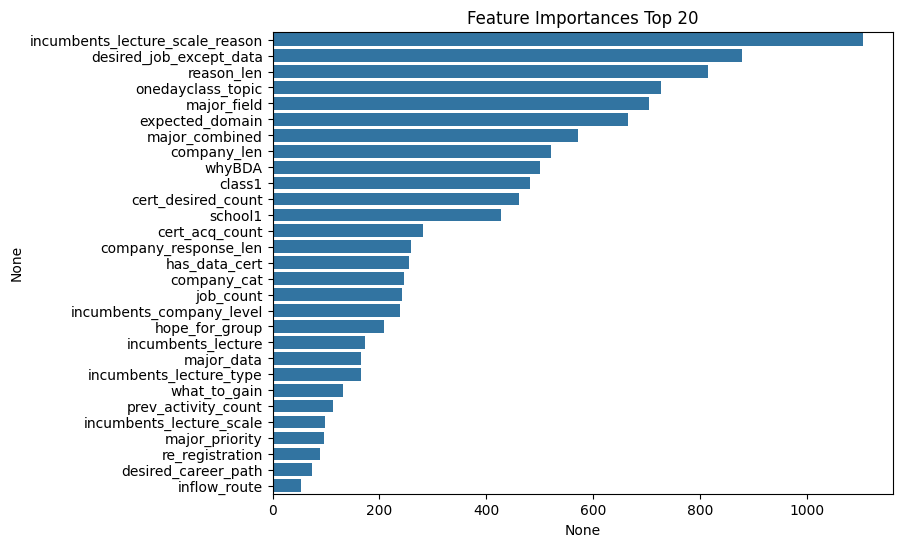

In [ ]:


# 마지막으로 학습된 model 객체 사용
ftr_importances_values = model.feature_importance()
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.title('Feature Importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()

In [ ]:
ftr_top20

,0
incumbents_lecture_scale_reason,1104
desired_job_except_data,878
reason_len,814
onedayclass_topic,727
major_field,703
expected_domain,664
major_combined,571
company_len,520
whyBDA,501
class1,481


🚀 최적 임계값(Best Threshold): 0.25
🎯 최고 F1-Score: 0.4722
📈 ROC-AUC Score: 0.5882

[Classification Report]
              precision    recall  f1-score   support

      미수료(0)       0.82      0.17      0.28       525
       수료(1)       0.32      0.91      0.47       223

    accuracy                           0.39       748
   macro avg       0.57      0.54      0.38       748
weighted avg       0.67      0.39      0.34       748



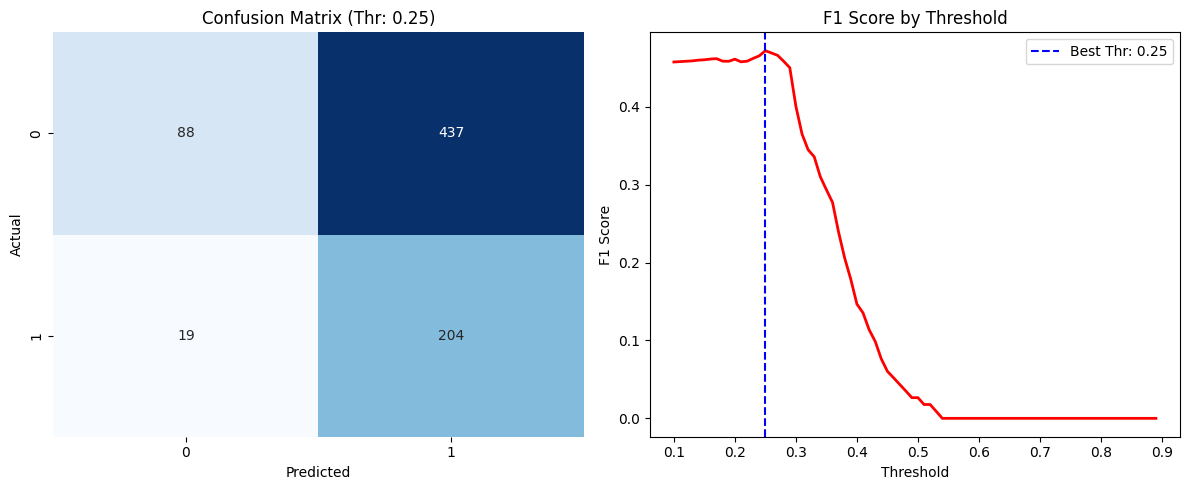

In [ ]:

# 1. 최적 임계값(Threshold) 찾기 (F1-score 극대화)
thresholds = np.arange(0.1, 0.9, 0.01)
f1_list = [f1_score(y_train, (oof_preds > thr).astype(int)) for thr in thresholds]
best_thr = thresholds[np.argmax(f1_list)]
best_f1 = np.max(f1_list)

# 2. 이진 분류 결과 생성
final_preds = (oof_preds > best_thr).astype(int)

# 3. 상세 리포트 출력
print("="*60)
print(f"🚀 최적 임계값(Best Threshold): {best_thr:.2f}")
print(f"🎯 최고 F1-Score: {best_f1:.4f}")
print(f"📈 ROC-AUC Score: {roc_auc_score(y_train, oof_preds):.4f}")
print("="*60)
print("\n[Classification Report]")
# 0: 미수료, 1: 수료 등 실제 클래스 이름에 맞춰 수정 가능
print(classification_report(y_train, final_preds, target_names=['미수료(0)', '수료(1)']))

# 4. 혼동 행렬(Confusion Matrix) 시각화
plt.figure(figsize=(12, 5))

# 혼동 행렬 히트맵
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_train, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (Thr: {best_thr:.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 임계값 변화에 따른 F1-score 그래프
plt.subplot(1, 2, 2)
plt.plot(thresholds, f1_list, color='red', lw=2)
plt.axvline(best_thr, color='blue', linestyle='--', label=f'Best Thr: {best_thr:.2f}')
plt.title('F1 Score by Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
train['completed'].value_counts()

,count
completed,
0,525
1,223


In [ ]:
submission['completed'].value_counts()

,count
completed,
1,547
0,267
